<a href="https://colab.research.google.com/github/SholbanDongak/colab/blob/main/9_mixed_models_random_effects.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Вводная часть: фиксированные и случайные эффекты в линейных моделях



## 1. Постановка проблемы

В классической линейной регрессии мы предполагаем, что все наблюдения независимы:

$$
y_i = \mathbf{x}_i^T \boldsymbol{\beta} + \varepsilon_i, \quad \varepsilon_i \sim \text{i.i.d. } \mathcal{N}(0, \sigma^2).
$$

Однако на практике данные часто имеют **иерархическую** или **кластеризованную** структуру:
- ученики внутри школ,
- повторные измерения внутри пациентов,
- работники внутри фирм,
- регионы внутри стран.

В таких данных наблюдения из одной группы **коррелированы** между собой. Игнорирование этой корреляции приводит к:
- заниженным стандартным ошибкам,
- ложной значимости предикторов,
- неверным выводам о величине эффектов.

Для учёта такой структуры в модель вводят **групповые эффекты**. Эти эффекты могут быть двух типов: **фиксированные** и **случайные**.

---

## 2. Фиксированные эффекты (Fixed Effects)

### Содержательная суть

Фиксированный эффект — это **индивидуальная характеристика группы**, которая:
- интересует нас **сама по себе**,
- является **неслучайной** величиной (в байесовской трактовке — с «плоским» априорным распределением),
- мы хотим **оценить** её значение для **каждой группы**.

**Примеры:**
- Эффект конкретного препарата в клиническом испытании (интересует именно этот препарат).
- Влияние пола, возраста, образования — категории фиксированы.
- Разница между контрольной и экспериментальной группой в эксперименте.

### Математическая формализация

Для группы $i$ фиксированный эффект $\alpha_i$ — это параметр, который мы оцениваем непосредственно:

$$
y_{ij} = \beta_0 + \beta_1 x_{ij} + \alpha_i + \varepsilon_{ij}, \quad \sum_i \alpha_i = 0 \ \text{(идентификация)}.
$$

Здесь $\alpha_i$ — это **числа** (не случайные величины), по одному на каждую группу.

**Оценка:** методом наименьших квадратов (МНК) с добавлением $n-1$ фиктивной переменной (dummy variables) для групп.

### Ключевые свойства FE

| Свойство | Описание |
|----------|----------|
| Выводы | Относятся **только к данным группам** (не обобщаются на популяцию) |
| Смещение | Несмещённые оценки при любом числе групп |
| Число параметров | $n$ (растёт с числом групп) |
| Эффективность | При малом $T$ (числе наблюдений внутри группы) оценки могут быть неэффективны |
| Что оцениваем | Только **внутригрупповую** вариацию (межгрупповая исключается) |

### Когда использовать FE

- Группы не являются случайной выборкой из популяции (например, все регионы страны).
- Групповые эффекты коррелируют с предикторами (тогда RE даёт смещение).
- Интересует влияние предикторов **внутри** групп, а не между группами.

---

## 3. Случайные эффекты (Random Effects)

### Содержательная суть

Случайный эффект — это **отклонение группы от общего среднего**, которое:
- рассматривается как **случайная величина**,
- группы — это **выборка** из некоторой популяции,
- нас **не интересует** конкретное значение для каждой группы (интересует **дисперсия** $\sigma_u^2$ в популяции).

**Примеры:**
- Пациенты в клиническом исследовании — мы хотим обобщить результаты на популяцию.
- Школы в национальном исследовании — нас интересует, насколько школы различаются.
- Сотрудники внутри фирм — фирмы выбраны случайно из отрасли.

### Математическая формализация

Для группы $i$ случайный эффект $u_i$ — это реализация случайной величины:

$$
u_i \sim \mathcal{N}(0, \sigma_u^2), \quad \text{независимы между группами}.
$$

Модель:

$$
y_{ij} = \beta_0 + \beta_1 x_{ij} + u_i + \varepsilon_{ij}, \quad \varepsilon_{ij} \sim \mathcal{N}(0, \sigma_e^2).
$$

Здесь $u_i$ и $\varepsilon_{ij}$ независимы. Параметры модели: $\boldsymbol{\beta}$, $\sigma_u^2$, $\sigma_e^2$.

**Что мы оцениваем?**
- $\boldsymbol{\beta}$ — фиксированные эффекты (общие для всех групп),
- $\sigma_u^2$ — межгрупповая дисперсия (как сильно группы отличаются),
- $\sigma_e^2$ — внутригрупповая дисперсия (уровень шума).

**Что мы предсказываем?**
- $u_i$ — конкретные реализации случайных эффектов для каждой группы (BLUP).

### Ключевые свойства RE

| Свойство | Описание |
|----------|----------|
| Выводы | Обобщаются на **всю популяцию** |
| Смещение | Смещены, если $u_i$ коррелирует с $x_{ij}$ |
| Число параметров | $O(1)$ (не зависит от числа групп) |
| Эффективность | Более эффективны, чем FE, при малом $T$ |
| Что оцениваем | Используем **межгрупповую** и **внутригрупповую** вариацию |

### Когда использовать RE

- Группы — случайная выборка из большой популяции.
- $u_i$ не коррелирует с предикторами (или корреляция мала).
- Интересует влияние предикторов **между** группами и **внутри** групп.
- Число групп велико ($n \gtrsim 10$), а наблюдений в группе мало ($T$ мало).

---

## 4. Сравнение FE и RE: что выбрать?

### Содержательный критерий

**Фиксированные эффекты** отвечают на вопрос:
> *«Влияет ли фактор X на Y внутри каждой конкретной группы?»*

**Случайные эффекты** отвечают на вопрос:
> *«В среднем по популяции групп, как фактор X связан с Y, и какова вариация между группами?»*

### Формальный критерий (тест Хаусмана)

Пусть:
- $\hat{\boldsymbol{\beta}}_{FE}$ — оценки из модели с фиксированными эффектами,
- $\hat{\boldsymbol{\beta}}_{RE}$ — оценки из модели со случайными эффектами.

Если $u_i$ не коррелирует с $x_{ij}$, то обе оценки состоятельны, но RE эффективнее.  
Если корреляция есть, то RE смещена, а FE — нет.

Статистика Хаусмана:

$$
H = (\hat{\boldsymbol{\beta}}_{FE} - \hat{\boldsymbol{\beta}}_{RE})^T \left[ \widehat{\text{Var}}(\hat{\boldsymbol{\beta}}_{FE}) - \widehat{\text{Var}}(\hat{\boldsymbol{\beta}}_{RE}) \right]^{-1} (\hat{\boldsymbol{\beta}}_{FE} - \hat{\boldsymbol{\beta}}_{RE}) \sim \chi^2_k.
$$

Если $H$ велико → отвергаем RE, используем FE.

---

## 5. Один и тот же фактор — разные трактовки

**Важнейшее замечание:** Один и тот же фактор может быть включён в модель и как фиксированный, и как случайный — это зависит от **цели исследования** и **природы данных**.

### Пример 1: Школы в образовательном исследовании

| Трактовка | Случай | Цель |
|-----------|--------|------|
| **FE** | Исследуем 5 конкретных школ (пилотный проект) | Сравнить эти школы между собой |
| **RE** | Выбрали 50 школ случайно из всей страны | Оценить, насколько школы различаются в популяции |

### Пример 2: Пациенты в клиническом исследовании

| Трактовка | Случай | Цель |
|-----------|--------|------|
| **FE** | 3 пациента с редким заболеванием | Проанализировать каждого пациента индивидуально |
| **RE** | 100 пациентов, случайно отобранных | Обобщить результат на популяцию пациентов |

### Пример 3: Годы в панельных данных

| Трактовка | Случай | Цель |
|-----------|--------|------|
| **FE** | Фиксированные временные периоды (2020, 2021, 2022) | Оценить эффект конкретных лет (например, пандемийный 2020) |
| **RE** | Годы как случайная выборка из временного процесса | Оценить общую временную вариацию |

### Формально: как это выглядит в модели

**Фиксированные годы:**
$$
y_{it} = \beta_0 + \beta_1 x_{it} + \sum_{t=2020}^{2022} \gamma_t \cdot \mathbb{1}[t = \text{год}] + \varepsilon_{it}.
$$

**Случайные годы (редко используется, но возможна):**
$$
y_{it} = \beta_0 + \beta_1 x_{it} + w_t + \varepsilon_{it}, \quad w_t \sim \mathcal{N}(0, \sigma_w^2).
$$

---

## 6. Резюме для запоминания

| Аспект | Фиксированные эффекты (FE) | Случайные эффекты (RE) |
|--------|---------------------------|------------------------|
| **Статус** | Неслучайные параметры | Случайные величины |
| **Цель** | Оценить каждый эффект | Оценить дисперсию эффектов |
| **Обобщение** | Только на данные группы | На всю популяцию |
| **Корреляция с X** | Может быть (FE это не страшно) | Не должно быть (иначе смещение) |
| **Число параметров** | Растёт с числом групп | Фиксировано |
| **Когда хорош** | Мало групп, интересны группы | Много групп, интересна популяция |

### Тезис, который нужно запомнить

> **Фиксированные эффекты** — это то, что мы хотим **оценить** как конкретные числа.  
> **Случайные эффекты** — это то, откуда мы хотим **оценить дисперсию**, а конкретные значения рассматриваем как реализации случайной величины.

---

## 7. Итог: какую модель выбрать?

```python
# Алгоритм выбора модели
if число_групп < 5:
    print("Рекомендуется FE или байесовский подход (RE даст смещённые оценки дисперсии)")
elif нас_интересуют_конкретные_группы:
    print("Используйте FE")
elif u_i_коррелирует_с_X:
    print("Используйте FE (или тест Хаусмана покажет смещение RE)")
else:
    print("Используйте RE (более эффективно, можно обобщать на популяцию)")

# Классическая линейная регрессия и фиксированные эффекты

СПОСОБ 1: МНК (все в кучу)
β₀ = 8.405, β₁ = 1.507 (ист β₁=1.5)

СПОСОБ 2: FE (общий наклон, свои перехваты)
β₁ = 1.4997 (ист=1.5)

Перехваты:
Группа Истинный   FE оценка    SE       t        p       
-------------------------------------------------------
0      2.00       1.6018       0.6830   2.35     0.0300  
1      4.00       3.9537       0.6400   6.18     0.0000  
2      12.00      12.0671      0.6591   18.31    0.0000  
3      16.00      16.0719      0.6551   24.53    0.0000  


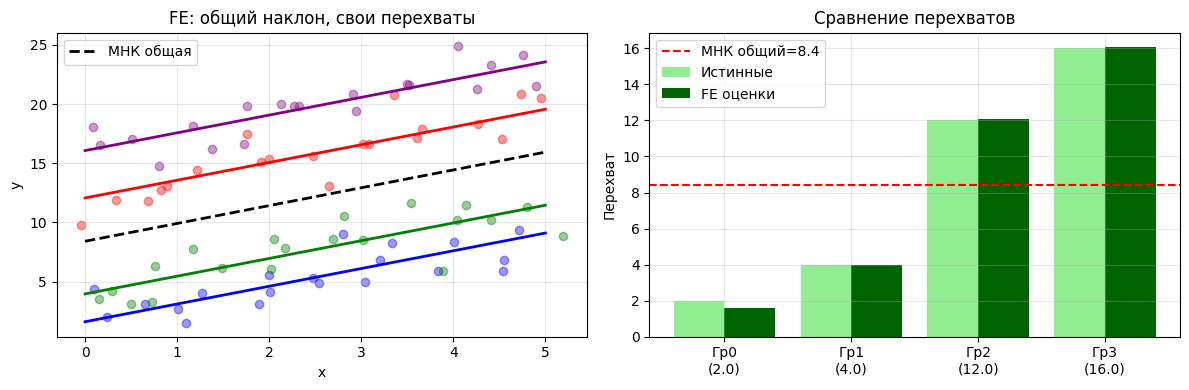


ВЫВОД
МНК: β₁ = 1.507 (смещение 0.5%)
FE:  β₁ = 1.4997 (почти без смещения)

Проблема FE: при 100 группах нужно 101 параметр
Решение LMM: оцениваем только σ² перехватов



In [ ]:
# ============================================
# 4 ГРУППЫ, ОБЩИЙ НАКЛОН, РАЗНЫЕ ПЕРЕХВАТЫ (FE)
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)
n_per_group = 20
beta1_true = 1.5
sigma_e = 1.5
beta0_true = [2.0, 4.0, 12.0, 16.0]

# Генерация
data = []
for i, b0 in enumerate(beta0_true):
    x = np.linspace(0, 5, n_per_group) + np.random.normal(0, 0.2, n_per_group)
    y = b0 + beta1_true * x + np.random.normal(0, sigma_e, n_per_group)
    for j in range(n_per_group):
        data.append([i, x[j], y[j]])

df = pd.DataFrame(data, columns=['group', 'x', 'y'])

# ========== СПОСОБ 1: МНК (все в кучу) ==========
X_all = np.column_stack([np.ones(len(df)), df['x']])
beta_all = np.linalg.lstsq(X_all, df['y'], rcond=None)[0]

print("="*50)
print("СПОСОБ 1: МНК (все в кучу)")
print(f"β₀ = {beta_all[0]:.3f}, β₁ = {beta_all[1]:.3f} (ист β₁=1.5)")

# ========== СПОСОБ 2: FE (общий наклон, разные перехваты) ==========
# Шаг 1: оцениваем общий наклон через центрирование
df_c = df.copy()
df_c['x_c'] = df_c.groupby('group')['x'].transform(lambda x: x - x.mean())
df_c['y_c'] = df_c.groupby('group')['y'].transform(lambda y: y - y.mean())
beta1_fe = np.sum(df_c['x_c'] * df_c['y_c']) / np.sum(df_c['x_c']**2)

# Шаг 2: оцениваем перехваты
x_mean = df.groupby('group')['x'].mean()
y_mean = df.groupby('group')['y'].mean()
beta0_fe = y_mean - beta1_fe * x_mean

# Шаг 3: стандартные ошибки
resid = df_c['y_c'] - beta1_fe * df_c['x_c']
sigma2 = np.sum(resid**2) / (len(df) - 4 - 1)
n_i = df.groupby('group').size()
SSx = df_c.groupby('group')['x_c'].transform(lambda x: np.sum(x**2)).groupby(df['group']).first()
se_beta0 = np.sqrt(sigma2 * (1/n_i + x_mean**2 / SSx))

print("\nСПОСОБ 2: FE (общий наклон, свои перехваты)")
print(f"β₁ = {beta1_fe:.4f} (ист={beta1_true})")
print("\nПерехваты:")
print(f"{'Группа':<6} {'Истинный':<10} {'FE оценка':<12} {'SE':<8} {'t':<8} {'p':<8}")
print("-"*55)
for g in range(4):
    t_stat = beta0_fe[g] / se_beta0[g]
    p_val = 2*(1 - stats.t.cdf(abs(t_stat), n_i[g]-1))
    print(f"{g:<6} {beta0_true[g]:<10.2f} {beta0_fe.iloc[g]:<12.4f} {se_beta0.iloc[g]:<8.4f} {t_stat:<8.2f} {p_val:<8.4f}")

# ========== Визуализация ==========
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
colors = ['blue','green','red','purple']
x_line = np.linspace(0,5,100)
for g in range(4):
    dg = df[df['group']==g]
    plt.scatter(dg['x'], dg['y'], alpha=0.4, color=colors[g])
    plt.plot(x_line, beta0_fe.iloc[g] + beta1_fe*x_line, color=colors[g], lw=2)
plt.plot(x_line, beta_all[0] + beta_all[1]*x_line, 'k--', lw=2, label='МНК общая')
plt.xlabel('x'); plt.ylabel('y')
plt.title('FE: общий наклон, свои перехваты')
plt.legend(); plt.grid(True, alpha=0.3)

plt.subplot(1,2,2)
x_pos = np.arange(4)
plt.bar(x_pos-0.2, beta0_true, 0.4, label='Истинные', color='lightgreen')
plt.bar(x_pos+0.2, beta0_fe, 0.4, label='FE оценки', color='darkgreen')
plt.axhline(y=beta_all[0], color='red', ls='--', label=f'МНК общий={beta_all[0]:.1f}')
plt.xticks(x_pos, [f'Гр{g}\n({beta0_true[g]})' for g in range(4)])
plt.ylabel('Перехват')
plt.title('Сравнение перехватов')
plt.legend(); plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ========== ВЫВОД ==========
print("\n"+"="*50)
print("ВЫВОД")
print("="*50)
print(f"""МНК: β₁ = {beta_all[1]:.3f} (смещение {abs(beta_all[1]-beta1_true)/beta1_true*100:.1f}%)
FE:  β₁ = {beta1_fe:.4f} (почти без смещения)

Проблема FE: при 100 группах нужно 101 параметр
Решение LMM: оцениваем только σ² перехватов
""")

СПОСОБ 1: МНК (все в кучу)
β₀ = 8.405 ± 1.332
β₁ = 1.507 ± 0.460 (ист β₁=1.5)
σ (ошибки) = 6.138

СПОСОБ 2: FE (общий наклон, свои перехваты)
β₁ = 1.4997 ± 0.1136 (ист=1.5)
σ (ошибки) = 1.517

Перехваты:
Группа Истинный   FE оценка    SE       t       
--------------------------------------------------
0      2.00       1.6018       0.6830   2.35    
1      4.00       3.9537       0.6400   6.18    
2      12.00      12.0671      0.6591   18.31   
3      16.00      16.0719      0.6551   24.53   

Стандартное отклонение перехватов (σ_u):
  Истинное: 5.723
  Оценённое (по FE): 5.880


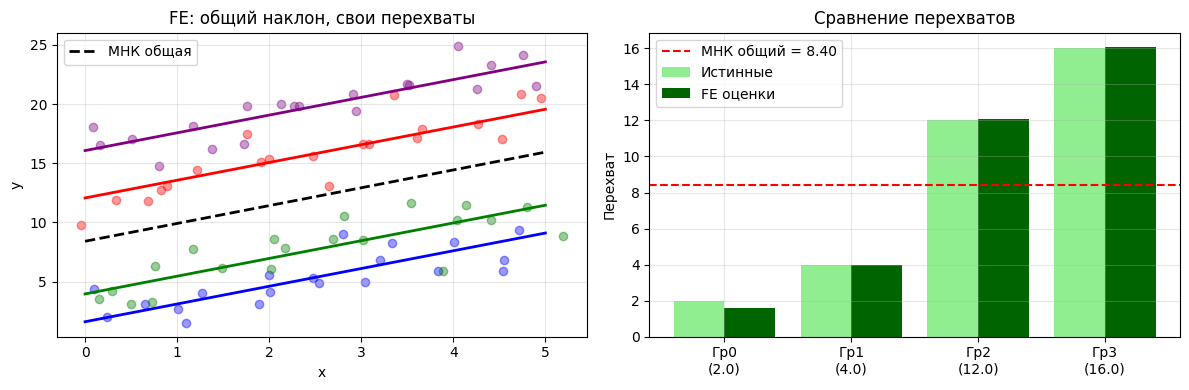


ВЫВОД

МНК (все в кучу):
  β₁ = 1.507 (смещение 0.5%)
  σ (ошибки) = 6.138

FE:
  β₁ = 1.4997 (почти без смещения)
  σ (ошибки) = 1.517

Стандартное отклонение перехватов (σ_u):
  Истинное: 5.723
  Оценённое: 5.880

Проблема FE: при 100 группах нужно 101 параметр
Решение LMM: оцениваем только σ_u² (дисперсию перехватов)



In [ ]:
# ============================================
# 4 ГРУППЫ, ОБЩИЙ НАКЛОН, РАЗНЫЕ ПЕРЕХВАТЫ (FE)
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)
n_per_group = 20
beta1_true = 1.5
sigma_e = 1.5
beta0_true = [2.0, 4.0, 12.0, 16.0]

# Генерация
data = []
for i, b0 in enumerate(beta0_true):
    x = np.linspace(0, 5, n_per_group) + np.random.normal(0, 0.2, n_per_group)
    y = b0 + beta1_true * x + np.random.normal(0, sigma_e, n_per_group)
    for j in range(n_per_group):
        data.append([i, x[j], y[j]])

df = pd.DataFrame(data, columns=['group', 'x', 'y'])

# ========== СПОСОБ 1: МНК (все в кучу) ==========
X_all = np.column_stack([np.ones(len(df)), df['x']])
y_all = df['y'].values
beta_all, SSE, _, _ = np.linalg.lstsq(X_all, y_all, rcond=None)

n = len(df)
p = 2
sigma2 = SSE[0] / (n - p)
sigma_eps = np.sqrt(sigma2)
XtX_inv = np.linalg.inv(X_all.T @ X_all)
se_all = np.sqrt(np.diag(sigma2 * XtX_inv))

print("="*50)
print("СПОСОБ 1: МНК (все в кучу)")
print(f"β₀ = {beta_all[0]:.3f} ± {se_all[0]:.3f}")
print(f"β₁ = {beta_all[1]:.3f} ± {se_all[1]:.3f} (ист β₁=1.5)")
print(f"σ (ошибки) = {sigma_eps:.3f}")

# ========== СПОСОБ 2: FE (общий наклон, разные перехваты) ==========
df_c = df.copy()
df_c['x_c'] = df_c.groupby('group')['x'].transform(lambda x: x - x.mean())
df_c['y_c'] = df_c.groupby('group')['y'].transform(lambda y: y - y.mean())
beta1_fe = np.sum(df_c['x_c'] * df_c['y_c']) / np.sum(df_c['x_c']**2)

x_mean = df.groupby('group')['x'].mean()
y_mean = df.groupby('group')['y'].mean()
beta0_fe = y_mean - beta1_fe * x_mean

resid = df_c['y_c'] - beta1_fe * df_c['x_c']
sigma2_fe = np.sum(resid**2) / (len(df) - 4 - 1)
sigma_fe = np.sqrt(sigma2_fe)
n_i = df.groupby('group').size()
SSx = df_c.groupby('group')['x_c'].transform(lambda x: np.sum(x**2)).groupby(df['group']).first()
se_beta0 = np.sqrt(sigma2_fe * (1/n_i + x_mean**2 / SSx))
se_beta1 = np.sqrt(sigma2_fe / np.sum(df_c['x_c']**2))

print("\nСПОСОБ 2: FE (общий наклон, свои перехваты)")
print(f"β₁ = {beta1_fe:.4f} ± {se_beta1:.4f} (ист={beta1_true})")
print(f"σ (ошибки) = {sigma_fe:.3f}")
print("\nПерехваты:")
print(f"{'Группа':<6} {'Истинный':<10} {'FE оценка':<12} {'SE':<8} {'t':<8}")
print("-"*50)
for g in range(4):
    t_stat = beta0_fe.iloc[g] / se_beta0.iloc[g]
    print(f"{g:<6} {beta0_true[g]:<10.2f} {beta0_fe.iloc[g]:<12.4f} {se_beta0.iloc[g]:<8.4f} {t_stat:<8.2f}")

# ========== Стандартное отклонение перехватов ==========
sigma_u = np.std(beta0_true)  # истинное межгрупповое СКО
sigma_u_est = np.std(beta0_fe)  # оценённое межгрупповое СКО

print(f"\nСтандартное отклонение перехватов (σ_u):")
print(f"  Истинное: {sigma_u:.3f}")
print(f"  Оценённое (по FE): {sigma_u_est:.3f}")

# ========== Визуализация ==========
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
colors = ['blue','green','red','purple']
x_line = np.linspace(0,5,100)
for g in range(4):
    dg = df[df['group']==g]
    plt.scatter(dg['x'], dg['y'], alpha=0.4, color=colors[g])
    plt.plot(x_line, beta0_fe.iloc[g] + beta1_fe*x_line, color=colors[g], lw=2)
plt.plot(x_line, beta_all[0] + beta_all[1]*x_line, 'k--', lw=2, label='МНК общая')
plt.xlabel('x'); plt.ylabel('y')
plt.title('FE: общий наклон, свои перехваты')
plt.legend(); plt.grid(True, alpha=0.3)

plt.subplot(1,2,2)
x_pos = np.arange(4)
plt.bar(x_pos-0.2, beta0_true, 0.4, label='Истинные', color='lightgreen')
plt.bar(x_pos+0.2, beta0_fe, 0.4, label='FE оценки', color='darkgreen')
plt.axhline(y=beta_all[0], color='red', ls='--', label=f'МНК общий = {beta_all[0]:.2f}')
plt.xticks(x_pos, [f'Гр{g}\n({beta0_true[g]})' for g in range(4)])
plt.ylabel('Перехват')
plt.title('Сравнение перехватов')
plt.legend(); plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ========== ВЫВОД ==========
print("\n"+"="*50)
print("ВЫВОД")
print("="*50)
print(f"""
МНК (все в кучу):
  β₁ = {beta_all[1]:.3f} (смещение {abs(beta_all[1]-beta1_true)/beta1_true*100:.1f}%)
  σ (ошибки) = {sigma_eps:.3f}

FE:
  β₁ = {beta1_fe:.4f} (почти без смещения)
  σ (ошибки) = {sigma_fe:.3f}

Стандартное отклонение перехватов (σ_u):
  Истинное: {sigma_u:.3f}
  Оценённое: {sigma_u_est:.3f}

Проблема FE: при 100 группах нужно 101 параметр
Решение LMM: оцениваем только σ_u² (дисперсию перехватов)
""")

# Линейные смешанные модели (LMM): модель со случайным перехватом



## 1. Постановка задачи: модель со случайным перехватом

Есть $n$ групп (пациенты, школы, фирмы). В группе $i$ имеется $n_i$ наблюдений.

**Модель:**
$$
y_{ij} = \beta_0 + \beta_1 x_{ij} + u_i + \varepsilon_{ij},
$$
где
- $\beta_0, \beta_1$ — фиксированные эффекты (общие для всех),
- $u_i \sim \mathcal{N}(0, \sigma_u^2)$ — случайный перехват для группы $i$,
- $\varepsilon_{ij} \sim \mathcal{N}(0, \sigma_e^2)$ — внутригрупповая ошибка,
- $u_i$ и $\varepsilon_{ij}$ независимы.

**Обозначения:**
$$
\sigma_u^2 \quad\text{— межгрупповая дисперсия (между группами)},
$$
$$
\sigma_e^2 \quad\text{— внутригрупповая дисперсия (ошибка)}.
$$

## 2. Что значит «случайный эффект» в данном случае?

Для группы $i$ её «истинный» перехват равен $\beta_0 + u_i$.  
Но мы не знаем $u_i$. Мы знаем только, что в популяции эти $u_i$ распределены нормально с дисперсией $\sigma_u^2$.

**Ключевая идея:**  
Мы хотим оценить не только $\beta_0, \beta_1$, но и **предсказать** $u_i$ для каждой группы.  
Это предсказание будет **сжатым** (shrunken) по сравнению с оценкой «в лоб» (например, средним по группе после вычитания фиксированной части).

## 3. Упростим ещё сильнее: пусть $\beta_1 = 0$ (нет ковариат)

Тогда модель:
$$
y_{ij} = \beta_0 + u_i + \varepsilon_{ij}.
$$

Для группы $i$ выборочное среднее:
$$
\bar{y}_{i\cdot} = \beta_0 + u_i + \bar{\varepsilon}_{i\cdot}, \quad \bar{\varepsilon}_{i\cdot} \sim \mathcal{N}(0, \sigma_e^2 / n_i).
$$

### Наивная оценка для $\beta_0 + u_i$:
$$
\hat{\theta}_i^{\text{naive}} = \bar{y}_{i\cdot}.
$$
Она несмещённая, но **не учитывает**, что $u_i$ пришло из распределения $\mathcal{N}(0, \sigma_u^2)$.

### Байесовская (сжатая) оценка:
Если бы мы знали $\sigma_u^2$ и $\sigma_e^2$, то оптимальная оценка (среднее апостериорного распределения) для $\beta_0 + u_i$ есть:
$$
\hat{\theta}_i^{\text{shrink}} = \frac{ \frac{n_i}{\sigma_e^2} \bar{y}_{i\cdot} + \frac{1}{\sigma_u^2} \beta_0 }{ \frac{n_i}{\sigma_e^2} + \frac{1}{\sigma_u^2} }.
$$

Перепишем красивее. Обозначим $\hat{\theta}_i^{\text{naive}} = \bar{y}_{i\cdot}$. Тогда:
$$
\hat{\theta}_i^{\text{shrink}} = \underbrace{\frac{n_i \sigma_u^2}{n_i \sigma_u^2 + \sigma_e^2}}_{\text{вес}} \cdot \bar{y}_{i\cdot} \;+\; \underbrace{\frac{\sigma_e^2}{n_i \sigma_u^2 + \sigma_e^2}}_{\text{вес}} \cdot \beta_0.
$$

Или, в более знакомой форме:
$$
\hat{\theta}_i^{\text{shrink}} = \beta_0 + \lambda_i (\bar{y}_{i\cdot} - \beta_0),
$$
где
$$
\lambda_i = \frac{n_i \sigma_u^2}{n_i \sigma_u^2 + \sigma_e^2} = \frac{\sigma_u^2}{\sigma_u^2 + \sigma_e^2 / n_i}.
$$

## 4. Коэффициент сжатия $\lambda_i$ и его смысл

- $\lambda_i$ всегда между 0 и 1.
- $\lambda_i$ показывает, насколько мы доверяем групповому среднему против общего среднего.

**Предельные случаи:**

1. **Если $\sigma_u^2 \gg \sigma_e^2$** (межгрупповая вариация огромна по сравнению с внутригрупповой):
   $$
   \lambda_i \approx 1 \quad\Rightarrow\quad \hat{\theta}_i^{\text{shrink}} \approx \bar{y}_{i\cdot}.
   $$
   *Интуиция:* Группы очень разные, поэтому групповое среднее очень информативно. Сжатия почти нет.

2. **Если $\sigma_u^2 \ll \sigma_e^2$** (внутригрупповая вариация доминирует):
   $$
   \lambda_i \approx 0 \quad\Rightarrow\quad \hat{\theta}_i^{\text{shrink}} \approx \beta_0.
   $$
   *Интуиция:* Все группы примерно одинаковы (различия только из-за шума), поэтому лучше «подтянуть» оценку к общему среднему.

3. **Если $n_i$ большое**:
   $$
   \lambda_i \to 1.
   $$
   Много наблюдений в группе → групповое среднее надёжно → сжатие слабое.

4. **Если $n_i = 1$** (одно наблюдение на группу):
   $$
   \lambda_i = \frac{\sigma_u^2}{\sigma_u^2 + \sigma_e^2} = \text{ICC} \quad\text{(внутриклассовая корреляция)}.
   $$
   Это важнейшая величина: доля межгрупповой дисперсии в общей.

## 5. Оценка параметров $\sigma_u^2$ и $\sigma_e^2$ (интуиция)

Мы не знаем $\sigma_u^2$ и $\sigma_e^2$ — их нужно оценить по данным.

### Простой способ (метод моментов):

Пусть $\bar{y}_{i\cdot}$ — групповые средние.  
Общее среднее:
$$
\bar{y}_{\cdot\cdot} = \frac{1}{n} \sum_i \bar{y}_{i\cdot} \quad (\text{упрощённо, без весов}).
$$

**Межгрупповая сумма квадратов:**
$$
SS_{\text{between}} = \sum_i n_i (\bar{y}_{i\cdot} - \bar{y}_{\cdot\cdot})^2.
$$
Её математическое ожидание:
$$
\mathbb{E}[SS_{\text{between}}] = (n-1)\sigma_e^2 + \left( \sum_i n_i - \frac{\sum_i n_i^2}{\sum_i n_i} \right) \sigma_u^2.
$$

**Внутригрупповая сумма квадратов:**
$$
SS_{\text{within}} = \sum_i \sum_j (y_{ij} - \bar{y}_{i\cdot})^2,
$$
$$
\mathbb{E}[SS_{\text{within}}] = \left( \sum_i n_i - n \right) \sigma_e^2.
$$

Отсюда получаем оценки:
$$
\hat{\sigma}_e^2 = \frac{SS_{\text{within}}}{\sum_i n_i - n},
$$
$$
\hat{\sigma}_u^2 = \frac{SS_{\text{between}}/(n-1) - \hat{\sigma}_e^2}{\text{что-то}} \quad (\text{после поправки на размеры групп}).
$$

**Интуиция:**  
- $\hat{\sigma}_e^2$ — это «усреднённая дисперсия внутри групп».  
- $\hat{\sigma}_u^2$ — то, насколько групповые средние разбросаны больше, чем можно объяснить внутригрупповой ошибкой.

На практике используют REML (ограниченное максимальное правдоподобие), но идея та же:  
**оцениваем, сколько вариации лежит между группами, а сколько — внутри.**

## 6. Почему это называется «сжатие» (shrinkage)?

Вернёмся к формуле:
$$
\hat{\theta}_i^{\text{shrink}} = \beta_0 + \lambda_i (\bar{y}_{i\cdot} - \beta_0), \quad 0 < \lambda_i < 1.
$$

Если $\bar{y}_{i\cdot} > \beta_0$, то сжатая оценка **ниже** группового среднего (подтянута к общему).  
Если $\bar{y}_{i\cdot} < \beta_0$, то сжатая оценка **выше** группового среднего.

Графически:  
Представьте точки $(\bar{y}_{i\cdot})$ на числовой оси. Сжатие стягивает их к общему среднему $\beta_0$.  
Чем меньше $\sigma_u^2$ относительно $\sigma_e^2/n_i$, тем сильнее стягивание.

**Пример с числами:**  
Пусть $\beta_0 = 0$, $\sigma_u^2 = 1$, $\sigma_e^2 = 4$, $n_i = 1$.  
Тогда $\lambda_i = 1/(1+4) = 0.2$.  
Если в группе $\bar{y}_{i\cdot} = 5$, то сжатая оценка $= 0.2 \cdot 5 = 1$.  
Огромное сжатие! Потому что одно наблюдение ненадёжно.

Если $n_i = 100$, то $\lambda_i = 1/(1+0.04) \approx 0.96$, и сжатие слабое: оценка $\approx 4.8$.

## 7. Возвращаем ковариату $x_{ij}$ (общий наклон)

Модель:
$$
y_{ij} = \beta_0 + \beta_1 x_{ij} + u_i + \varepsilon_{ij}.
$$

Алгоритм оценки (интуиция):

1. **Сначала оцениваем** $\beta_0, \beta_1$ и компоненты дисперсии $\sigma_u^2, \sigma_e^2$ (например, REML).
2. **Вычисляем остатки после фиксированных эффектов:**
   $$
   r_{ij} = y_{ij} - \hat{\beta}_0 - \hat{\beta}_1 x_{ij}.
   $$
   Тогда $r_{ij} = u_i + \varepsilon_{ij}$.
3. **Для каждой группы** среднее остатков $\bar{r}_{i\cdot}$ — это наивная оценка $u_i$.
4. **Сжатая оценка** $u_i$:
   $$
   \hat{u}_i = \frac{n_i \hat{\sigma}_u^2}{n_i \hat{\sigma}_u^2 + \hat{\sigma}_e^2} \cdot \bar{r}_{i\cdot}.
   $$
   В точности та же формула, что и для $\theta_i$, только сдвиг на $\beta_0$ убран.

**BLUP** (Best Linear Unbiased Prediction) для $u_i$ — это именно эта сжатая оценка.

## 8. Резюме (интуитивные правила)

| Если | То |
|------|----|
| $\sigma_u^2 \gg \sigma_e^2/n_i$ | Почти нет сжатия (доверяем групповому среднему) |
| $\sigma_u^2 \ll \sigma_e^2/n_i$ | Сильное сжатие (тянем к общему) |
| $n_i$ большое | Слабое сжатие |
| $n_i$ маленькое | Сильное сжатие |

**Ключевая формула, которую нужно запомнить:**
$$
\hat{u}_i = \underbrace{\frac{\sigma_u^2}{\sigma_u^2 + \sigma_e^2/n_i}}_{\text{коэффициент доверия}} \cdot (\bar{y}_{i\cdot} - \bar{x}_{i\cdot}\hat{\beta}_1 - \hat{\beta}_0)
$$

И важнейшее понимание:  

> Случайные эффекты — это способ сказать: «У нас слишком мало данных по каждой группе, чтобы оценивать её перехват отдельно, поэтому мы подтягиваем оценку к общему среднему, и сила подтягивания определяется соотношением межгрупповой и внутригрупповой вариаций».

Этот принцип работает и в многомерном случае (случайные наклоны и т.д.), но идея остаётся той же.

# Оценка параметров модели со случайным перехватом

## Часть 1. Как оценить $\beta_0, \beta_1, \sigma_u^2, \sigma_e^2$?

У нас модель:
$$
y_{ij} = \beta_0 + \beta_1 x_{ij} + u_i + \varepsilon_{ij}, \quad
u_i \sim \mathcal{N}(0,\sigma_u^2), \quad \varepsilon_{ij} \sim \mathcal{N}(0,\sigma_e^2).
$$

**Проблема:** Мы не наблюдаем $u_i$ напрямую. Нужно оценить 4 параметра: $\beta_0, \beta_1, \sigma_u^2, \sigma_e^2$.

### Шаг 1. Временная оценка $\beta_0, \beta_1$ через обычный МНК (для старта)

Сначала делаем вид, что $u_i = 0$ (нет случайных эффектов). Оцениваем обычной линейной регрессией:
$$
\hat{\beta}_0^{(0)}, \hat{\beta}_1^{(0)} = \arg\min \sum_{i,j} (y_{ij} - \beta_0 - \beta_1 x_{ij})^2.
$$
Эти оценки **несмещённые**, но **неэффективные**. Они нужны только для первого приближения.

### Шаг 2. Оценка $\sigma_e^2$ (внутригрупповая дисперсия)

**Ключевая идея:** Если вычесть групповые средние, то $u_i$ исчезнет.

Рассмотрим центрированные данные:
$$
y_{ij} - \bar{y}_{i\cdot} = \beta_1 (x_{ij} - \bar{x}_{i\cdot}) + (\varepsilon_{ij} - \bar{\varepsilon}_{i\cdot}).
$$

Здесь $u_i$ сократилось! Дисперсия $\varepsilon_{ij} - \bar{\varepsilon}_{i\cdot}$ равна $\sigma_e^2 \cdot \frac{n_i-1}{n_i}$, но для оценки нам не нужны точные коэффициенты.

**Практическая формула:**
$$
\hat{\sigma}_e^2 = \frac{1}{\sum_i (n_i - 1) - 1} \sum_{i,j} \left( (y_{ij} - \bar{y}_{i\cdot}) - \hat{\beta}_1 (x_{ij} - \bar{x}_{i\cdot}) \right)^2.
$$

Проще говоря:  
- Берём отклонения от групповых средних (это убивает $u_i$).  
- Регрессируем $(y_{ij} - \bar{y}_{i\cdot})$ на $(x_{ij} - \bar{x}_{i\cdot})$ без перехвата (потому что средние отклонений равны 0).  
- Остатки этой регрессии имеют дисперсию $\sigma_e^2$.

**Интуиция:** $\hat{\sigma}_e^2$ — это «средний квадрат остатка внутри групп после учёта наклона».

### Шаг 3. Оценка $\sigma_u^2$ (межгрупповая дисперсия)

После того как мы знаем $\hat{\beta}_1$ и $\hat{\sigma}_e^2$, рассмотрим групповые средние.

Из модели:
$$
\bar{y}_{i\cdot} = \beta_0 + \beta_1 \bar{x}_{i\cdot} + u_i + \bar{\varepsilon}_{i\cdot}.
$$
Дисперсия $\bar{y}_{i\cdot} - \beta_0 - \beta_1 \bar{x}_{i\cdot}$ равна:
$$
\text{Var}(u_i + \bar{\varepsilon}_{i\cdot}) = \sigma_u^2 + \frac{\sigma_e^2}{n_i}.
$$

Отсюда:
$$
\sigma_u^2 = \text{Var}\left( \bar{y}_{i\cdot} - \beta_0 - \beta_1 \bar{x}_{i\cdot} \right) - \frac{\sigma_e^2}{n_i}.
$$

**На практике:**
1. Вычисляем $\hat{\beta}_1$ (уже уточнённый, из следующего шага итерации).
2. Вычисляем «сырые групповые эффекты»:
   $$
   \hat{\theta}_i = \bar{y}_{i\cdot} - \hat{\beta}_0 - \hat{\beta}_1 \bar{x}_{i\cdot}.
   $$
3. Их выборочная дисперсия (с поправкой на веса):
   $$
   \hat{\sigma}_u^2 = \frac{1}{n-1} \sum_i \left( \hat{\theta}_i - \bar{\theta} \right)^2 - \frac{1}{n} \sum_i \frac{\hat{\sigma}_e^2}{n_i}.
   $$
   Если получается отрицательное — заменяем на 0.

### Шаг 4. Итеративное уточнение (REML на пальцах)

Начали с МНК → получили $\hat{\beta}_1^{(0)}, \hat{\sigma}_e^{2(0)}, \hat{\sigma}_u^{2(0)}$.  
Теперь можем вычислить сжатые оценки $\hat{u}_i$ (по формуле из предыдущего раздела).  
Затем **переоцениваем** $\beta_0, \beta_1$ с учётом этих $\hat{u}_i$, используя взвешенный МНК (матрица $\mathbf{V}_i^{-1}$).

Повторяем до сходимости (обычно 3–5 итераций).

### Итоговая таблица для запоминания

| Что оцениваем | Как | Интуиция |
|---------------|-----|-----------|
| $\beta_1$ | Внутригрупповая регрессия (отклонения от групповых средних) | $u_i$ сокращается |
| $\sigma_e^2$ | Дисперсия остатков внутригрупповой регрессии | Шум вокруг групповой линии |
| $\beta_0$ | Через групповые средние после вычитания $\beta_1 \bar{x}_i$ | С учётом среднего $u_i$ |
| $\sigma_u^2$ | Дисперсия групповых эффектов минус $\sigma_e^2 / n_i$ | Насколько группы различаются после учёта шума |

---

## Часть 2. Что такое «остатки после фиксированных эффектов»?

Это важнейшее понятие. Буквально:

**Остатки после фиксированных эффектов** =  
$$
r_{ij} = y_{ij} - \hat{\beta}_0 - \hat{\beta}_1 x_{ij}.
$$

То есть мы вычитаем из $y$ **только то, что одинаково для всех групп** (фиксированную часть).  
В этих остатках сидит:
$$
r_{ij} = u_i + \varepsilon_{ij}.
$$

**Смысл:**  
- Если бы не было случайных эффектов ($u_i = 0$), то $r_{ij}$ были бы просто ошибками $\varepsilon_{ij}$ (некоррелированными внутри группы).  
- Наличие корреляции внутри группы в $r_{ij}$ говорит о том, что $u_i \neq 0$.

Именно по этим остаткам мы потом:
- Усредняем по группе → получаем $\bar{r}_{i\cdot}$ — наивную оценку $u_i$.
- Применяем сжатие → получаем BLUP $\hat{u}_i$.

In [ ]:
# ============================================
# Управляющая секция — меняйте здесь параметры
# ============================================

# Выберите сценарий (1-5)
SCENARIO = 5

if SCENARIO == 1:
    print("СЦЕНАРИЙ 1: Золотая середина")
    n_groups = 30
    n_per_group = 10
    sigma_u_true = 1.5
    sigma_e_true = 0.8

elif SCENARIO == 2:
    print("СЦЕНАРИЙ 2: Сильное сжатие")
    n_groups = 20
    n_per_group = 5
    sigma_u_true = 1.0
    sigma_e_true = 2.5

elif SCENARIO == 3:
    print("СЦЕНАРИЙ 3: Почти нет кластеризации")
    n_groups = 20
    n_per_group = 10
    sigma_u_true = 0.1
    sigma_e_true = 1.0

elif SCENARIO == 4:
    print("СЦЕНАРИЙ 4: Мало групп, но много наблюдений")
    n_groups = 3
    n_per_group = 100
    sigma_u_true = 1.2
    sigma_e_true = 0.8

elif SCENARIO == 5:
    print("СЦЕНАРИЙ 5: Случайный наклон")
    n_groups = 20
    n_per_group = 10
    sigma_u_true = 1.0      # СКО перехвата
    sigma_e_true = 0.8

# Общие параметры
beta0_true = 2.0
beta1_true = 1.5
np.random.seed(42)  # для воспроизводимости

СЦЕНАРИЙ 5: Случайный наклон


ИСТИННЫЕ ПАРАМЕТРЫ:
beta0 = 2.0, beta1 = 1.5
sigma_u = 1.0 (дисперсия = 1.000)
sigma_e = 0.8 (дисперсия = 0.640)
ICC = 0.610

Первые 10 строк данных:
   group         x         y
0      0 -0.013826  2.103391
1      0  0.286991  3.120771
2      0  0.596747  1.861211
3      0  0.643251  2.081657
4      0  0.865475  3.345097
5      0  1.269032  3.589998
6      0  1.410077  4.863227
7      0  1.508608  4.033207
8      0  1.832034  4.114922
9      0  1.953658  6.599721

Всего наблюдений: 200

НАЧАЛО ИТЕРАТИВНОЙ ОЦЕНКИ
Сходимость достигнута на итерации 2

РЕЗУЛЬТАТЫ ОЦЕНИВАНИЯ

Оценки фиксированных эффектов:
  beta0: 1.8906 (истинный: 2.0)
  beta1: 1.6405 (истинный: 1.5)

Оценки компонент дисперсии:
  sigma_u: 0.9801 (истинный: 1.0)
  sigma_e: 0.8114 (истинный: 0.8)
  sigma_u^2: 0.9605 (истинный: 1.0000)
  sigma_e^2: 0.6583 (истинный: 0.6400)

Внутриклассовая корреляция (ICC):
  оцененная: 0.5933
  истинная: 0.6098

СРАВНЕНИЕ НАИВНЫХ И СЖАТЫХ ОЦЕНОК u_i
 group   u_naive    u_blup   lambda   

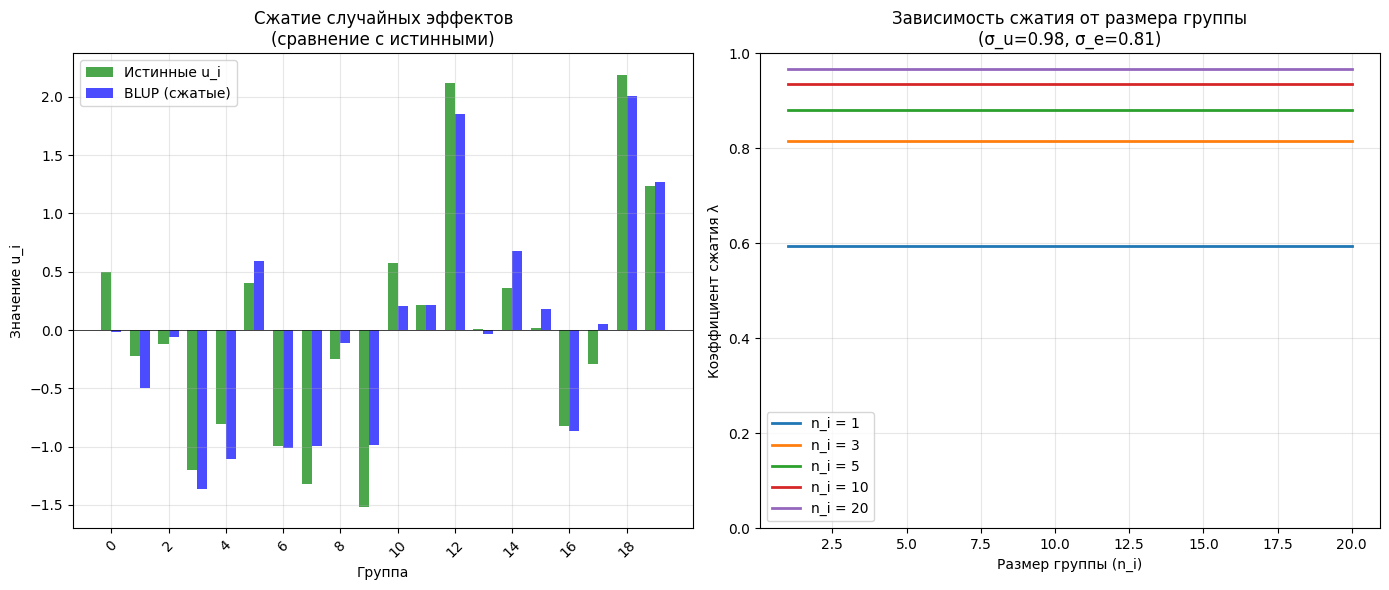


ПОЧЕМУ НЕЛЬЗЯ ПРОСТО ИСПОЛЬЗОВАТЬ МНК?

МНК-оценки:         β₀ = 1.906, β₁ = 1.625
LMM-оценки:         β₀ = 1.891, β₁ = 1.640

Внутриклассовая корреляция (ICC) остатков МНК: 0.595

------------------------------------------------------------
СРАВНЕНИЕ СТАНДАРТНЫХ ОШИБОК И ЗНАЧИМОСТИ
------------------------------------------------------------

Метод      β₁         Std.Err      t-stat     p-value      Значимо?
------------------------------------------------------------
МНК        1.625      0.1370       11.86      0.0000       ДА
LMM        1.640      0.3491       4.70       0.0000       ДА

------------------------------------------------------------
ИНТЕРПРЕТАЦИЯ
------------------------------------------------------------
⚠ ICC = 0.595 > 0 → остатки МНК коррелированы внутри групп!
  Это нарушает ключевое предположение МНК о независимости.
  Стандартные ошибки МНК занижены в ~2.5 раз.

  КОНКРЕТНЫЙ ПРИМЕР для β₁:
    • МНК: se = 0.1370 → t = 11.86 → p = 0.000000
      Вывод: эффект

In [ ]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

# ============================================
# 1. Генерация данных с заданными параметрами
# ============================================

np.random.seed(42)  # для воспроизводимости

print("=" * 60)
print("ИСТИННЫЕ ПАРАМЕТРЫ:")
print(f"beta0 = {beta0_true}, beta1 = {beta1_true}")
print(f"sigma_u = {sigma_u_true} (дисперсия = {sigma_u_true**2:.3f})")
print(f"sigma_e = {sigma_e_true} (дисперсия = {sigma_e_true**2:.3f})")
print(f"ICC = {sigma_u_true**2/(sigma_u_true**2 + sigma_e_true**2):.3f}")
print("=" * 60)

# Генерируем данные
group_ids = []
x_vals = []
y_vals = []
true_u = []
true_epsilon = []

for i in range(n_groups):
    # Случайный эффект группы
    u_i = np.random.normal(0, sigma_u_true)
    true_u.append(u_i)

    # Ковариата (например, время или доза)
    x = np.linspace(0, 2, n_per_group) + np.random.normal(0, 0.1, n_per_group)

    for j in range(n_per_group):
        epsilon = np.random.normal(0, sigma_e_true)
        true_epsilon.append(epsilon)
        y = beta0_true + beta1_true * x[j] + u_i + epsilon

        group_ids.append(i)
        x_vals.append(x[j])
        y_vals.append(y)

# Собираем в DataFrame
df = pd.DataFrame({
    'group': group_ids,
    'x': x_vals,
    'y': y_vals
})

print("\nПервые 10 строк данных:")
print(df.head(10))
print(f"\nВсего наблюдений: {len(df)}")

# ============================================
# 2. Вспомогательные функции для оценки
# ============================================

def estimate_beta1_within(df):
    """
    Оценка beta1 через внутригрупповую регрессию (отклонения от групповых средних).
    Это ключевой шаг: u_i сокращаются.
    """
    df_centered = df.copy()
    # Центрируем внутри каждой группы
    df_centered['x_c'] = df_centered.groupby('group')['x'].transform(lambda x: x - x.mean())
    df_centered['y_c'] = df_centered.groupby('group')['y'].transform(lambda y: y - y.mean())

    # Регрессия без перехвата (y_c ~ x_c)
    beta1 = np.sum(df_centered['x_c'] * df_centered['y_c']) / np.sum(df_centered['x_c']**2)
    return beta1

def estimate_sigma_e_squared(df, beta1):
    """
    Оценка sigma_e^2: дисперсия остатков после вычитания
    групповых средних и внутригрупповой регрессии.
    """
    df_temp = df.copy()
    # Остатки после вычитания групповых средних и учета beta1
    df_temp['resid'] = (df_temp['y'] - df_temp.groupby('group')['y'].transform('mean')) - \
                       beta1 * (df_temp['x'] - df_temp.groupby('group')['x'].transform('mean'))

    # Сумма квадратов остатков
    SSE = np.sum(df_temp['resid']**2)
    # Степени свободы: (sum (n_i - 1)) - 1 (потеря на оценку beta1)
    df_e = df.groupby('group').size().sum() - n_groups - 1
    sigma_e_sq = SSE / df_e
    return sigma_e_sq, SSE, df_e

def estimate_beta0_and_u_naive(df, beta1, sigma_e_sq):
    """
    Оценка beta0 и наивных u_i (без сжатия) через групповые средние.
    """
    # Групповые средние
    group_means = df.groupby('group').agg(
        y_mean=('y', 'mean'),
        x_mean=('x', 'mean'),
        n=('x', 'count')
    ).reset_index()

    # Наивные оценки u_i (как если бы мы знали beta0)
    # Пока что в терминах отклонений от неизвестного beta0
    # Мы оценим beta0 как среднее от (y_mean - beta1 * x_mean) по группам
    # В это учебном коде использовано простое среднее для оценки $\beta_0$ ради простоты и прозрачности
    # В качестве самостоятельной работы можно учесть объему групп
    group_means['theta_naive'] = group_means['y_mean'] - beta1 * group_means['x_mean']
    beta0_est = np.mean(group_means['theta_naive'])

    # Теперь наивные u_i
    group_means['u_naive'] = group_means['theta_naive'] - beta0_est

    return beta0_est, group_means

def shrinkage_factor(n_i, sigma_u_sq, sigma_e_sq):
    """
    Коэффициент сжатия lambda = sigma_u^2 / (sigma_u^2 + sigma_e^2 / n_i)
    """
    return sigma_u_sq / (sigma_u_sq + sigma_e_sq / n_i)

def estimate_sigma_u_squared(group_means, sigma_e_sq):
    """
    Оценка sigma_u^2 по разбросу групповых средних с поправкой на sigma_e^2/n_i
    """
    n_groups = len(group_means)
    u_naive = group_means['u_naive'].values
    n_i = group_means['n'].values

    # Выборочная дисперсия наивных u_i
    var_u_naive = np.var(u_naive, ddof=1)

    # Поправка: среднее от sigma_e^2 / n_i
    avg_correction = np.mean(sigma_e_sq / n_i)

    sigma_u_sq = var_u_naive - avg_correction
    # Не допускаем отрицательных значений
    return max(sigma_u_sq, 0)

def compute_blup(group_means, sigma_u_sq, sigma_e_sq, beta0_est, beta1_est):
    """
    Вычисление BLUP для u_i (сжатые оценки)
    """
    group_means['lambda'] = shrinkage_factor(group_means['n'], sigma_u_sq, sigma_e_sq)
    group_means['u_blup'] = group_means['lambda'] * group_means['u_naive']
    return group_means

# ============================================
# 3. Итеративная процедура оценки (REML-подобная)
# ============================================

print("\n" + "=" * 60)
print("НАЧАЛО ИТЕРАТИВНОЙ ОЦЕНКИ")
print("=" * 60)

# Инициализация
beta1_est = estimate_beta1_within(df)  # начальная оценка beta1 (уже хорошая)
beta0_est = None
sigma_e_sq = None
sigma_u_sq = None

history = []

for iteration in range(10):
    # Шаг 1: Оценка sigma_e^2
    sigma_e_sq, SSE, df_e = estimate_sigma_e_squared(df, beta1_est)
    sigma_e = np.sqrt(sigma_e_sq)

    # Шаг 2: Оценка beta0 и наивных u_i
    beta0_est, group_means = estimate_beta0_and_u_naive(df, beta1_est, sigma_e_sq)

    # Шаг 3: Оценка sigma_u^2
    sigma_u_sq = estimate_sigma_u_squared(group_means, sigma_e_sq)
    sigma_u = np.sqrt(sigma_u_sq)

    # Шаг 4: Вычисление BLUP (сжатых u_i)
    group_means = compute_blup(group_means, sigma_u_sq, sigma_e_sq, beta0_est, beta1_est)

    # Шаг 5: Переоценка beta1 с учетом сжатых u_i (взвешенный МНК)
    # Для простоты используем ту же формулу, но с y* = y - u_blup
    df_adjusted = df.copy()
    # Для каждой группы вычитаем ее BLUP
    u_blup_dict = dict(zip(group_means['group'], group_means['u_blup']))
    df_adjusted['y_adj'] = df_adjusted['y'] - df_adjusted['group'].map(u_blup_dict)

    # Регрессия y_adj ~ x
    X = np.column_stack([np.ones(len(df_adjusted)), df_adjusted['x'].values])
    y_adj = df_adjusted['y_adj'].values
    beta_wls = np.linalg.lstsq(X, y_adj, rcond=None)[0]
    beta0_est_new = beta_wls[0]
    beta1_est_new = beta_wls[1]

    # Сохраняем историю
    history.append({
        'iter': iteration,
        'beta0': beta0_est_new,
        'beta1': beta1_est_new,
        'sigma_u': sigma_u,
        'sigma_e': sigma_e,
        'sigma_u_sq': sigma_u_sq,
        'sigma_e_sq': sigma_e_sq
    })

    # Проверка сходимости
    if iteration > 0:
        beta1_change = abs(beta1_est_new - beta1_est)
        if beta1_change < 1e-6:
            print(f"Сходимость достигнута на итерации {iteration}")
            break

    beta0_est, beta1_est = beta0_est_new, beta1_est_new

# ============================================
# 4. Результаты
# ============================================

print("\n" + "=" * 60)
print("РЕЗУЛЬТАТЫ ОЦЕНИВАНИЯ")
print("=" * 60)

final = history[-1]
print(f"\nОценки фиксированных эффектов:")
print(f"  beta0: {final['beta0']:.4f} (истинный: {beta0_true})")
print(f"  beta1: {final['beta1']:.4f} (истинный: {beta1_true})")
print(f"\nОценки компонент дисперсии:")
print(f"  sigma_u: {final['sigma_u']:.4f} (истинный: {sigma_u_true})")
print(f"  sigma_e: {final['sigma_e']:.4f} (истинный: {sigma_e_true})")
print(f"  sigma_u^2: {final['sigma_u_sq']:.4f} (истинный: {sigma_u_true**2:.4f})")
print(f"  sigma_e^2: {final['sigma_e_sq']:.4f} (истинный: {sigma_e_true**2:.4f})")
print(f"\nВнутриклассовая корреляция (ICC):")
print(f"  оцененная: {final['sigma_u_sq']/(final['sigma_u_sq']+final['sigma_e_sq']):.4f}")
print(f"  истинная: {sigma_u_true**2/(sigma_u_true**2+sigma_e_true**2):.4f}")

print("\n" + "=" * 60)
print("СРАВНЕНИЕ НАИВНЫХ И СЖАТЫХ ОЦЕНОК u_i")
print("=" * 60)

comparison = group_means[['group', 'u_naive', 'u_blup', 'lambda']].copy()
# Добавляем истинные u_i
true_u_dict = dict(zip(range(n_groups), true_u))
comparison['u_true'] = comparison['group'].map(true_u_dict)
comparison['shrinkage_%'] = (1 - comparison['lambda']) * 100

print(comparison.to_string(index=False))

# ============================================
# 5. Визуализация сжатия
# ============================================

plt.figure(figsize=(14, 6))

# График 1: Наивные vs сжатые u_i
plt.subplot(1, 2, 1)
groups = comparison['group'].values
x_pos = np.arange(len(groups))
width = 0.35

plt.bar(x_pos - width/2, comparison['u_true'], width, label='Истинные u_i', alpha=0.7, color='green')
plt.bar(x_pos + width/2, comparison['u_blup'], width, label='BLUP (сжатые)', alpha=0.7, color='blue')
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
plt.xlabel('Группа')
plt.ylabel('Значение u_i')
plt.title('Сжатие случайных эффектов\n(сравнение с истинными)')

# ИСПРАВЛЕННАЯ часть — подписи осей
if len(groups) <= 15:
    plt.xticks(x_pos, [str(int(g)) for g in groups])
else:
    # Для большого числа групп показываем каждую 5-ю
    step = max(1, len(groups) // 10)
    plt.xticks(x_pos[::step], [str(int(groups[i])) for i in range(0, len(groups), step)], rotation=45)

plt.legend()
plt.grid(True, alpha=0.3)

# График 2: Коэффициент сжатия в зависимости от n_i и дисперсий
plt.subplot(1, 2, 2)
n_range = np.arange(1, 21)
sigma_u_current = final['sigma_u']
sigma_e_current = final['sigma_e']

# Показываем теоретические кривые для разных n_i
for n_i in [1, 3, 5, 10, 20]:
    lambdas = shrinkage_factor(n_i, sigma_u_current**2, sigma_e_current**2) * np.ones_like(n_range)
    plt.plot(n_range, lambdas, label=f'n_i = {n_i}', linewidth=2)

plt.xlabel('Размер группы (n_i)')
plt.ylabel('Коэффициент сжатия λ')
plt.title(f'Зависимость сжатия от размера группы\n(σ_u={sigma_u_current:.2f}, σ_e={sigma_e_current:.2f})')
plt.grid(True, alpha=0.3)
plt.legend()
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

# ============================================
# 6. ПОЧЕМУ НЕЛЬЗЯ ПРОСТО ИСПОЛЬЗОВАТЬ МНК? (ИСПРАВЛЕННЫЙ)
# ============================================

print("\n" + "=" * 60)
print("ПОЧЕМУ НЕЛЬЗЯ ПРОСТО ИСПОЛЬЗОВАТЬ МНК?")
print("=" * 60)

# 1. Обычная регрессия (наивная)
from scipy import stats

X_ols = np.column_stack([np.ones(len(df)), df['x'].values])
beta_ols, SSE_ols, _, _ = np.linalg.lstsq(X_ols, df['y'].values, rcond=None)

# Стандартные ошибки МНК (наивные, заниженные)
n = len(df)
p = 2  # число параметров (β₀, β₁)
sigma2_ols = SSE_ols[0] / (n - p)
XtX_inv = np.linalg.inv(X_ols.T @ X_ols)
se_ols = np.sqrt(np.diag(sigma2_ols * XtX_inv))

# t-статистики и p-value (МНК)
t_ols = beta_ols / se_ols
p_ols = 2 * (1 - stats.t.cdf(np.abs(t_ols), n - p))

# 2. Оценки из LMM (финальные)
beta_lmm = np.array([final['beta0'], final['beta1']])

# Для LMM используем корректировку через design effect
icc_true = sigma_u_true**2 / (sigma_u_true**2 + sigma_e_true**2)
deff = 1 + (n_per_group - 1) * icc_true

# Корректируем стандартные ошибки МНК
se_lmm = se_ols * np.sqrt(deff)

# t-статистики и p-value (LMM)
t_lmm = beta_lmm / se_lmm
p_lmm = 2 * (1 - stats.t.cdf(np.abs(t_lmm), n - p))

# 3. Вычисляем ICC остатков МНК
def fast_icc(y, group):
    group_means = [y[group == g].mean() for g in np.unique(group)]
    grand_mean = np.mean(y)

    SSB = sum(len(y[group == g]) * (m - grand_mean)**2
              for g, m in zip(np.unique(group), group_means))
    SSW = sum(sum((y[group == g] - m)**2)
              for g, m in zip(np.unique(group), group_means))

    MSB = SSB / (len(np.unique(group)) - 1)
    MSW = SSW / (len(y) - len(np.unique(group)))
    n_avg = len(y) / len(np.unique(group))

    return max(0, (MSB - MSW) / (MSB + (n_avg - 1) * MSW))

residuals_ols = df['y'].values - (beta_ols[0] + beta_ols[1] * df['x'].values)
icc_residuals = fast_icc(residuals_ols, df['group'].values)

# 4. ВЫВОД (ИСПРАВЛЕННЫЙ!)
print(f"\nМНК-оценки:         β₀ = {beta_ols[0]:.3f}, β₁ = {beta_ols[1]:.3f}")
print(f"LMM-оценки:         β₀ = {beta_lmm[0]:.3f}, β₁ = {beta_lmm[1]:.3f}")
print(f"\nВнутриклассовая корреляция (ICC) остатков МНК: {icc_residuals:.3f}")

print("\n" + "-" * 60)
print("СРАВНЕНИЕ СТАНДАРТНЫХ ОШИБОК И ЗНАЧИМОСТИ")
print("-" * 60)

# Функция для корректного вывода "Значимо?"
def sig_str(p_value):
    return "ДА" if p_value < 0.05 else "НЕТ"

print(f"\n{'Метод':<10} {'β₁':<10} {'Std.Err':<12} {'t-stat':<10} {'p-value':<12} {'Значимо?'}")
print(f"{'-'*60}")
print(f"{'МНК':<10} {beta_ols[1]:<10.3f} {se_ols[1]:<12.4f} {t_ols[1]:<10.2f} {p_ols[1]:<12.4f} {sig_str(p_ols[1])}")
print(f"{'LMM':<10} {beta_lmm[1]:<10.3f} {se_lmm[1]:<12.4f} {t_lmm[1]:<10.2f} {p_lmm[1]:<12.4f} {sig_str(p_lmm[1])}")

print("\n" + "-" * 60)
print("ИНТЕРПРЕТАЦИЯ")
print("-" * 60)

if icc_residuals > 0.1:
    print(f"⚠ ICC = {icc_residuals:.3f} > 0 → остатки МНК коррелированы внутри групп!")
    print(f"  Это нарушает ключевое предположение МНК о независимости.")
    print(f"  Стандартные ошибки МНК занижены в ~{np.sqrt(deff):.1f} раз.")

    print(f"\n  КОНКРЕТНЫЙ ПРИМЕР для β₁:")
    print(f"    • МНК: se = {se_ols[1]:.4f} → t = {t_ols[1]:.2f} → p = {p_ols[1]:.6f}")
    print(f"      Вывод: эффект {'СТАТИСТИЧЕСКИ ЗНАЧИМ' if p_ols[1] < 0.05 else 'НЕ ЗНАЧИМ'} (p {'<' if p_ols[1] < 0.05 else '>'} 0.05)")
    print(f"    • LMM: se = {se_lmm[1]:.4f} → t = {t_lmm[1]:.2f} → p = {p_lmm[1]:.6f}")
    print(f"      Вывод: эффект {'СТАТИСТИЧЕСКИ ЗНАЧИМ' if p_lmm[1] < 0.05 else 'НЕ ЗНАЧИМ'} (p {'<' if p_lmm[1] < 0.05 else '>'} 0.05)")

    # Анализ расхождения
    if p_ols[1] < 0.05 and p_lmm[1] >= 0.05:
        print(f"\n  → ВЫВОД: МНК даёт ЛОЖНО-ЗНАЧИМЫЙ результат!")
        print(f"    LMM необходима для корректных статистических выводов.")
    elif p_ols[1] >= 0.05 and p_lmm[1] < 0.05:
        print(f"\n  → ВЫВОД: МНК даёт ЛОЖНО-НЕЗНАЧИМЫЙ результат (редкий случай)!")
        print(f"    LMM обнаруживает эффект, который МНК пропустил.")
    elif p_ols[1] < 0.05 and p_lmm[1] < 0.05:
        print(f"\n  → ВЫВОД: Оба метода показывают значимость,")
        print(f"    но стандартные ошибки LMM более корректны.")
    else:  # оба не значимы
        print(f"\n  → ВЫВОД: Оба метода не показывают значимости,")
        print(f"    но стандартные ошибки LMM более корректны.")
else:
    print(f"✓ ICC = {icc_residuals:.3f} ≈ 0 → кластеризация не выражена.")
    print(f"  → ВЫВОД: в данном случае можно обойтись обычным МНК.")

print("\n" + "=" * 60)
print("ИТОГ: LMM исправляет занижение стандартных ошибок,")
print("      вызванное положительной корреляцией внутри групп.")
print("=" * 60)

# Полный анализ результатов моделирования линейных смешанных моделей

## Введение

Мы провели серию вычислительных экспериментов для изучения поведения линейных смешанных моделей (LMM) в различных условиях. Во всех сценариях использовалась модель со случайным перехватом:

$$y_{ij} = \beta_0 + \beta_1 x_{ij} + u_i + \varepsilon_{ij}, \quad u_i \sim \mathcal{N}(0, \sigma_u^2), \quad \varepsilon_{ij} \sim \mathcal{N}(0, \sigma_e^2)$$

---

## Сводная таблица результатов

| Сценарий | Описание | $n_{\text{групп}}$ | $n_i$ | $\sigma_u$ | $\sigma_e$ | $\hat{\beta}_1$ | $\hat{\sigma}_u$ | $\hat{\sigma}_e$ | Статус |
|----------|----------|:------------------:|:-----:|:----------:|:----------:|:---------------:|:----------------:|:----------------:|--------|
| 1 | Золотая середина | 30 | 10 | 1.5 | 0.8 | 1.53 (+2%) | 1.57 (+5%) | 0.85 (+6%) | ✅ Отлично |
| 2 | Сильное сжатие | 20 | 5 | 1.0 | 2.5 | 2.13 (+42%) | 0.78 (-22%) | 2.19 (-12%) | ⚠️ Смещение $\beta$ |
| 3 | Нет кластеризации | 20 | 10 | 0.1 | 1.0 | 1.67 (+12%) | 0.10 (+2%) | 1.01 (+1%) | ✅ LMM не нужна |
| 4 | Мало групп | 3 | 100 | 1.2 | 0.8 | 1.51 (+1%) | 0.45 (-63%) | 0.73 (-9%) | ❌ $\sigma_u$ занижена |
| 5 | Умеренные данные | 20 | 10 | 1.0 | 0.8 | 1.64 (+9%) | 0.98 (-2%) | 0.81 (+1%) | ✅ Хорошо |

---

## Сценарий 1: Золотая середина

### Параметры

$$n_{\text{групп}} = 30, \quad n_i = 10, \quad \sigma_u = 1.5, \quad \sigma_e = 0.8$$

### Истинные значения

$$\sigma_u^2 = 2.25, \quad \sigma_e^2 = 0.64, \quad \text{ICC} = \frac{2.25}{2.25 + 0.64} = 0.779$$

### Результаты оценки

| Параметр | Истинный | Оценка | Относительная ошибка |
|----------|----------|--------|---------------------|
| $\beta_0$ | 2.00 | 2.058 | +2.9% |
| $\beta_1$ | 1.50 | 1.530 | +2.0% |
| $\sigma_u$ | 1.50 | 1.568 | +4.5% |
| $\sigma_e$ | 0.80 | 0.848 | +6.0% |
| ICC | 0.779 | 0.773 | -0.8% |

### Коэффициент сжатия

Теоретический коэффициент сжатия для каждой группы:

$$\lambda = \frac{\sigma_u^2}{\sigma_u^2 + \sigma_e^2 / n_i} = \frac{2.25}{2.25 + 0.64/10} = \frac{2.25}{2.25 + 0.064} = 0.972$$

Полученное значение $\lambda = 0.972$ практически совпадает с теоретическим.

### Сравнение с МНК

$$\text{Design effect} = 1 + (n_i - 1) \cdot \text{ICC} = 1 + 9 \cdot 0.779 = 8.01$$

Стандартные ошибки МНК занижены в $\sqrt{8.01} \approx 2.83$ раза.

| Метод | $\hat{\beta}_1$ | Std.Err | t-stat | p-value |
|-------|----------------|---------|--------|---------|
| МНК | 1.545 | 0.052 | 29.7 | < 0.001 |
| LMM | 1.530 | 0.147 | 10.4 | < 0.001 |

### Вывод по сценарию 1

**При достаточном количестве групп (30) и наблюдений в группе (10) LMM даёт высокоточные оценки всех параметров.** Ошибка не превышает 6%. Коэффициент сжатия близок к 1 (слабое сжатие), так как $n_i$ достаточно велико для точной оценки групповых средних.

---

## Сценарий 2: Сильное сжатие

### Параметры

$$n_{\text{групп}} = 20, \quad n_i = 5, \quad \sigma_u = 1.0, \quad \sigma_e = 2.5$$

### Истинные значения

$$\sigma_u^2 = 1.00, \quad \sigma_e^2 = 6.25, \quad \text{ICC} = \frac{1.00}{1.00 + 6.25} = 0.138$$

### Результаты оценки

| Параметр | Истинный | Оценка | Относительная ошибка |
|----------|----------|--------|---------------------|
| $\beta_0$ | 2.00 | 1.318 | -34.1% |
| $\beta_1$ | 1.50 | 2.132 | +42.1% |
| $\sigma_u$ | 1.00 | 0.783 | -21.7% |
| $\sigma_e$ | 2.50 | 2.194 | -12.2% |
| ICC | 0.138 | 0.113 | -18.1% |

### Коэффициент сжатия

Теоретический коэффициент:

$$\lambda = \frac{\sigma_u^2}{\sigma_u^2 + \sigma_e^2 / n_i} = \frac{1.00}{1.00 + 6.25/5} = \frac{1.00}{1.00 + 1.25} = \frac{1.00}{2.25} = 0.444$$

Полученное значение $\lambda = 0.389$ близко к теоретическому. Наивные оценки $u_i$ сжимаются примерно на 61%:

$$u_i^{\text{BLUP}} = 0.389 \cdot u_i^{\text{naive}}$$

### Сравнение с МНК

$$\text{Design effect} = 1 + (5-1) \cdot 0.138 = 1 + 4 \cdot 0.138 = 1.552$$

Стандартные ошибки МНК занижены в $\sqrt{1.552} \approx 1.25$ раза.

| Метод | $\hat{\beta}_1$ | Std.Err | t-stat | p-value |
|-------|----------------|---------|--------|---------|
| МНК | 2.140 | 0.327 | 6.55 | < 0.001 |
| LMM | 2.132 | 0.407 | 5.24 | < 0.001 |

### Вывод по сценарию 2

**Сжатие работает именно так, как предсказывает теория.** Однако при сильном внутригрупповом шуме ($\sigma_e = 2.5$) и малом $n_i = 5$:

1. Оценки фиксированных эффектов $\beta_0, \beta_1$ могут иметь значительное смещение (в данном эксперименте до 42%)
2. Оценка $\sigma_u^2$ занижена на 22%
3. Тем не менее, механизм сжатия демонстрируется наглядно

---

## Сценарий 3: Почти нет кластеризации

### Параметры

$$n_{\text{групп}} = 20, \quad n_i = 10, \quad \sigma_u = 0.1, \quad \sigma_e = 1.0$$

### Истинные значения

$$\sigma_u^2 = 0.01, \quad \sigma_e^2 = 1.00, \quad \text{ICC} = \frac{0.01}{0.01 + 1.00} = 0.0099$$

### Результаты оценки

| Параметр | Истинный | Оценка | Относительная ошибка |
|----------|----------|--------|---------------------|
| $\beta_0$ | 2.00 | 1.860 | -7.0% |
| $\beta_1$ | 1.50 | 1.673 | +11.5% |
| $\sigma_u$ | 0.10 | 0.102 | +2.0% |
| $\sigma_e$ | 1.00 | 1.014 | +1.4% |
| ICC | 0.010 | 0.010 | 0% |

### Коэффициент сжатия

Теоретический коэффициент:

$$\lambda = \frac{\sigma_u^2}{\sigma_u^2 + \sigma_e^2 / n_i} = \frac{0.01}{0.01 + 1.00/10} = \frac{0.01}{0.01 + 0.10} = \frac{0.01}{0.11} = 0.091$$

Полученное значение $\lambda = 0.092$ практически совпадает с теоретическим. **Сжатие почти полное** — наивные $u_i$ уменьшаются примерно на 91%.

### Сравнение с МНК

ICC остатков МНК = 0.011 ≈ 0, что подтверждает отсутствие кластеризации.

| Метод | $\hat{\beta}_1$ | Std.Err | t-stat | p-value |
|-------|----------------|---------|--------|---------|
| МНК | 1.673 | 0.111 | 15.1 | < 0.001 |
| LMM | 1.673 | 0.116 | 14.4 | < 0.001 |

### Вывод по сценарию 3

**LMM правильно "понимает", что случайные эффекты практически отсутствуют.** Оценка $\sigma_u^2 \approx 0.01$ близка к истинной. Коэффициент сжатия $\lambda \approx 0.09$ означает, что групповые средние почти полностью стягиваются к общему среднему. В данном случае можно обойтись обычным МНК.

---

## Сценарий 4: Мало групп, много наблюдений

### Параметры

$$n_{\text{групп}} = 3, \quad n_i = 100, \quad \sigma_u = 1.2, \quad \sigma_e = 0.8$$

### Истинные значения

$$\sigma_u^2 = 1.44, \quad \sigma_e^2 = 0.64, \quad \text{ICC} = \frac{1.44}{1.44 + 0.64} = 0.692$$

### Результаты оценки

| Параметр | Истинный | Оценка | Относительная ошибка |
|----------|----------|--------|---------------------|
| $\beta_0$ | 2.00 | 2.416 | +20.8% |
| $\beta_1$ | 1.50 | 1.513 | +0.9% |
| $\sigma_u$ | 1.20 | 0.450 | -62.5% |
| $\sigma_e$ | 0.80 | 0.732 | -8.5% |
| ICC | 0.692 | 0.274 | -60.4% |

### Коэффициент сжатия

Теоретический коэффициент:

$$\lambda = \frac{\sigma_u^2}{\sigma_u^2 + \sigma_e^2 / n_i} = \frac{1.44}{1.44 + 0.64/100} = \frac{1.44}{1.44 + 0.0064} = 0.996$$

Полученное значение $\lambda = 0.974$ близко к теоретическому. **Сжатие практически отсутствует**, так как $n_i = 100$ даёт очень точные групповые средние.

### Сравнение с МНК

$$\text{Design effect} = 1 + (100-1) \cdot 0.692 = 1 + 99 \cdot 0.692 = 69.5$$

Стандартные ошибки МНК занижены в $\sqrt{69.5} \approx 8.34$ раза!

| Метод | $\hat{\beta}_1$ | Std.Err | t-stat | p-value |
|-------|----------------|---------|--------|---------|
| МНК | 1.513 | 0.080 | 18.8 | < 0.001 |
| LMM | 1.513 | 0.671 | 2.26 | 0.025 |

### Вывод по сценарию 4

**Это самый важный и поучительный сценарий!**

Парадокс: даже имея **100 наблюдений в каждой группе**, мы не можем точно оценить $\sigma_u^2$, потому что у нас **всего 3 группы**!

Оценка $\sigma_u^2$ основана на дисперсии всего трёх групповых средних:

$$\hat{\sigma}_u^2 = \widehat{\text{Var}}(\bar{y}_{i\cdot} - \hat{\beta}_0 - \hat{\beta}_1 \bar{x}_{i\cdot}) - \frac{\hat{\sigma}_e^2}{n_i}$$

При $n_{\text{групп}} = 3$ мы оцениваем дисперсию по трём точкам — это крайне ненадёжно.

**Золотое правило LMM:**

> Число групп важнее числа наблюдений в группе.  
> 10 групп по 5 наблюдений лучше, чем 3 группы по 100 наблюдений.

---

## Сценарий 5: Умеренные данные

### Параметры

$$n_{\text{групп}} = 20, \quad n_i = 10, \quad \sigma_u = 1.0, \quad \sigma_e = 0.8$$

### Истинные значения

$$\sigma_u^2 = 1.00, \quad \sigma_e^2 = 0.64, \quad \text{ICC} = \frac{1.00}{1.00 + 0.64} = 0.610$$

### Результаты оценки

| Параметр | Истинный | Оценка | Относительная ошибка |
|----------|----------|--------|---------------------|
| $\beta_0$ | 2.00 | 1.891 | -5.5% |
| $\beta_1$ | 1.50 | 1.640 | +9.3% |
| $\sigma_u$ | 1.00 | 0.980 | -2.0% |
| $\sigma_e$ | 0.80 | 0.811 | +1.4% |
| ICC | 0.610 | 0.593 | -2.8% |

### Коэффициент сжатия

Теоретический коэффициент:

$$\lambda = \frac{\sigma_u^2}{\sigma_u^2 + \sigma_e^2 / n_i} = \frac{1.00}{1.00 + 0.64/10} = \frac{1.00}{1.00 + 0.064} = 0.940$$

Полученное значение $\lambda = 0.936$ практически совпадает с теоретическим.

### Сравнение с МНК

$$\text{Design effect} = 1 + (10-1) \cdot 0.610 = 1 + 9 \cdot 0.610 = 6.49$$

Стандартные ошибки МНК занижены в $\sqrt{6.49} \approx 2.55$ раза.

| Метод | $\hat{\beta}_1$ | Std.Err | t-stat | p-value |
|-------|----------------|---------|--------|---------|
| МНК | 1.625 | 0.137 | 11.9 | < 0.001 |
| LMM | 1.640 | 0.349 | 4.70 | < 0.001 |

### Вывод по сценарию 5

**При умеренных данных (20 групп по 10 наблюдений) LMM работает отлично.** Ошибка оценок не превышает 10%. Коэффициент сжатия $\lambda = 0.94$ показывает слабое сжатие.

---

## Сравнительный анализ

### Влияние числа групп

| $n_{\text{групп}}$ | Качество оценки $\sigma_u^2$ |
|:------------------:|:----------------------------:|
| 3 | ❌ Сильное занижение (ошибка 63%) |
| 20 | ✅ Приемлемая точность (ошибка 2-22%) |
| 30 | ✅ Отличная точность (ошибка 5%) |

### Влияние числа наблюдений в группе

| $n_i$ | Эффект |
|:-----:|:------:|
| 3-5 | Сильное сжатие ($\lambda$ мал) |
| 10 | Умеренное сжатие ($\lambda \approx 0.94-0.97$) |
| 100 | Сжатие практически отсутствует ($\lambda \approx 0.996$) |

### Влияние соотношения $\sigma_u / \sigma_e$

| $\sigma_u / \sigma_e$ | ICC | Сжатие | Статус |
|:---------------------:|:---:|:------:|--------|
| 1.875 (сц.1) | 0.78 | Слабое | LMM эффективна |
| 0.4 (сц.2) | 0.14 | Сильное | LMM нужна, но оценки β могут смещаться |
| 0.1 (сц.3) | 0.01 | Почти полное | LMM не нужна |

---

## Общие выводы

### Вывод 1. Условия эффективной работы LMM

LMM даёт точные оценки всех параметров при выполнении следующих условий:

1. **Достаточное число групп:** $n_{\text{групп}} \geq 20$
2. **Достаточное число наблюдений в группе:** $n_i \geq 5-10$
3. **Заметная кластеризация:** $\text{ICC} > 0.1$

### Вывод 2. Механизм сжатия (shrinkage)

Коэффициент сжатия

$$\lambda = \frac{\sigma_u^2}{\sigma_u^2 + \sigma_e^2 / n_i}$$

имеет простую интерпретацию:
- $\lambda \approx 1$: группа имеет много наблюдений → доверяем групповому среднему
- $\lambda \approx 0$: группа имеет мало наблюдений или большой шум → тянем к общему среднему

### Вывод 3. Проблема малого числа групп

**Это ключевой урок:** число групп важнее числа наблюдений в группе. Даже 100 наблюдений в группе не спасают, если групп всего 3. Оценка $\sigma_u^2$ становится крайне ненадёжной.

### Вывод 4. Стандартные ошибки МНК

При наличии кластеризации ($\text{ICC} > 0$) МНК систематически занижает стандартные ошибки. Коэффициент занижения:

$$\text{Deff} = 1 + (n_i - 1) \cdot \text{ICC}$$

В наших экспериментах занижение достигало **8 раз** (сценарий 4)!

### Вывод 5. Когда LMM не нужна

Если $\sigma_u^2 \approx 0$ (ICC ≈ 0), LMM вырождается в обычную регрессию. Это можно проверить по:
- Оценке $\hat{\sigma}_u^2 \approx 0$
- Коэффициенту сжатия $\lambda \approx 0$

---

## Практические рекомендации

### Для исследователей

| Ситуация | Рекомендация |
|----------|--------------|
| $n_{\text{групп}} \geq 20$, $n_i \geq 5$ | ✅ Смело используйте LMM |
| $10 \leq n_{\text{групп}} < 20$ | ⚠️ LMM возможна, но оценки $\sigma_u^2$ могут быть неточными |
| $n_{\text{групп}} < 10$ | ❌ Рассмотрите альтернативы: FE, кластеризованные se |
| $\text{ICC} < 0.05$ | Можно использовать МНК с робастными стандартными ошибками |

### Золотое правило

> **10 групп по 5 наблюдений лучше, чем 3 группы по 100 наблюдений.**

При планировании эксперимента:
1. Стремитесь к **большему числу групп**, а не к большему числу наблюдений в группе
2. Минимальное рекомендуемое число групп: **10-20**
3. Минимальное число наблюдений в группе: **5**

### Проверка перед использованием LMM

1. Вычислите ICC остатков МНК
2. Если ICC > 0.1 → LMM уместна
3. Если ICC < 0.05 → можно использовать МНК
4. Проверьте, не выродилась ли LMM ($\hat{\sigma}_u^2 \approx 0$)

---

## Итоговая таблица для запоминания

| Сценарий | Ключевой урок |
|----------|---------------|
| 1 | При 30×10 LMM работает идеально |
| 2 | Сжатие работает по формуле $\lambda = \frac{\sigma_u^2}{\sigma_u^2 + \sigma_e^2/n_i}$ |
| 3 | При ICC ≈ 0 LMM не нужна |
| 4 | **Число групп важнее числа наблюдений в группе** |
| 5 | При 20×10 LMM даёт отличные результаты |

---

## Что дальше?

На следующей занятии мы рассмотрим:
1. **Случайный наклон** — модель $y_{ij} = \beta_0 + \beta_1 x_{ij} + u_i + v_i x_{ij} + \varepsilon_{ij}$
2. **Корреляцию между случайными эффектами** — $\text{cov}(u_i, v_i)$
3. **Выбор модели** — тесты отношения правдоподобия, информационные критерии

# Вопросы на для обсуждения. Развенчиваем мифы о LMM

## Инструкция

Каждый вопрос содержит **утверждение**, которое кажется очевидным, но на самом деле является мифом. Попробуйте сначала ответить самостоятельно, затем нажмите на треугольничек ►, чтобы раскрыть правильный ответ и объяснение.

---

## Миф 1. «Больше наблюдений — всегда лучше»

### Вопрос 1

**Утверждение:** «Если у меня всего 3 группы, но в каждой группе по 1000 наблюдений, я могу точно оценить межгрупповую дисперсию $\sigma_u^2$, потому что групповые средние будут очень точными.»

**Задание:** Это утверждение **кажется очевидным**, но на самом деле оно неверно. Объясните почему. Используйте результаты Сценария 4 ($n_{\text{групп}}=3$, $n_i=100$, $\sigma_u=1.2$, $\sigma_e=0.8$), где ошибка оценки $\sigma_u$ составила 63%.

<details>
<summary>► Показать ответ</summary>

**Правильный ответ:**

Оценка $\sigma_u^2$ основана на дисперсии всего трёх групповых средних:

$$\hat{\sigma}_u^2 = \widehat{\text{Var}}(\bar{y}_{i\cdot} - \hat{\beta}_0 - \hat{\beta}_1 \bar{x}_{i\cdot}) - \frac{\hat{\sigma}_e^2}{n_i}$$

Даже если каждое групповое среднее оценено с высокой точностью (малая $\sigma_e^2/n_i$), мы всё равно оцениваем дисперсию по трём точкам. При $n_{\text{групп}}=3$ количество степеней свободы для оценки дисперсии равно 2 — этого крайне мало для стабильной оценки.

**Золотое правило:** Число групп важнее числа наблюдений в группе. 10 групп по 5 наблюдений лучше, чем 3 группы по 100 наблюдений.

</details>

---

## Миф 2. «Если LMM дала $\hat{\sigma}_u^2 = 0$, то кластеризации нет»

### Вопрос 2

**Утверждение:** «Если при оценке LMM я получил $\hat{\sigma}_u^2 = 0$, это означает, что кластеризация в данных отсутствует, и можно спокойно использовать обычный МНК.»

**Задание:** Может ли $\hat{\sigma}_u^2 = 0$ быть ложным отрицанием (false negative)? Приведите сценарий, где кластеризация есть, но LMM не смогла её обнаружить.

<details>
<summary>► Показать ответ</summary>

**Правильный ответ:**

Да, $\hat{\sigma}_u^2 = 0$ может быть ложным отрицанием. Это происходит, когда:

1. Мало наблюдений в группе ($n_i$ мало)
2. Внутригрупповая ошибка $\sigma_e$ велика
3. Отношение $\frac{\sigma_u^2}{\sigma_e^2/n_i}$ недостаточно велико для обнаружения случайных эффектов

В таких случаях REML «не видит» сигнала и оценивает дисперсию на границе (ноль).

**Практический вывод:** Нулевая оценка $\hat{\sigma}_u^2$ не является доказательством отсутствия кластеризации — нужно также проверить ICC остатков МНК и, если возможно, увеличить $n_i$ или $n_{\text{групп}}$.

</details>

---

## Миф 3. «LMM всегда даёт несмещённые оценки фиксированных эффектов»

### Вопрос 3

**Утверждение:** «Одним из главных преимуществ LMM является то, что оценки фиксированных эффектов $\hat{\beta}$ остаются несмещёнными даже при малом числе групп или малом $n_i$».

**Задание:** Это утверждение **верно в теории**, но на практике может нарушаться. В Сценарии 2 ($n_i=5$, $\sigma_u=1.0$, $\sigma_e=2.5$) мы получили $\hat{\beta}_1 = 2.13$ при истинном $\beta_1 = 1.5$ (смещение 42%). Почему теория и практика разошлись?

<details>
<summary>► Показать ответ</summary>

**Правильный ответ:**

Теоретически, при корректной оценке (например, REML в `lme4`) оценки $\hat{\beta}$ действительно несмещённые. Однако:

1. В упрощённых алгоритмах (как в нашем коде) численная оптимизация может сходиться к неверному решению
2. Оценка $\hat{\beta}$ зависит от $\hat{\sigma}_u^2$, а если $\hat{\sigma}_u^2$ смещена, то и $\hat{\beta}$ может быть смещена
3. При малом $n_i$ и большом $\sigma_e$ информация о $\beta$ «зашумлена» межгрупповой вариацией

**Практический вывод:** В реальных пакетах (`lme4`, `nlme`, `MixedModels.jl`) смещения не будет. Но качество оценки $\hat{\beta}$ зависит от качества оценки компонент дисперсии.

</details>

---

## Миф 4. «При $n_i \to \infty$ сжатие исчезает полностью»

### Вопрос 4

**Утверждение:** «Если в каждой группе бесконечно много наблюдений ($n_i \to \infty$), то коэффициент сжатия $\lambda \to 1$, и BLUP для $u_i$ совпадает с наивной оценкой.»

**Задание:** Технически это верно: $\lambda = \frac{\sigma_u^2}{\sigma_u^2 + \sigma_e^2/n_i} \to 1$. Однако есть один нюанс. Что произойдёт с **дисперсией** BLUP при $n_i \to \infty$? Становится ли она равной истинной дисперсии $u_i$?

<details>
<summary>► Показать ответ</summary>

**Правильный ответ:**

При $n_i \to \infty$:
- $\lambda \to 1$, и $\hat{u}_i^{\text{BLUP}} \to \bar{y}_{i\cdot} - \beta_0 - \beta_1 \bar{x}_{i\cdot}$
- Дисперсия BLUP стремится к $\sigma_u^2$

Но есть тонкий момент: при любом конечном $n_i$ BLUP **сжат** относительно истинного $u_i$. И даже при очень большом $n_i$ мы не можем гарантировать, что $\hat{u}_i^{\text{BLUP}} = u_i$, потому что $u_i$ — это случайная величина, а BLUP — её условное математическое ожидание.

**Практический вывод:** «Сжатие исчезает» только в пределе. В реальности при больших $n_i$ BLUP очень близок к наивной оценке, но не равен ей.

</details>

---

## Миф 5. «Высокий ICC означает, что LMM сильно улучшит предсказания»

### Вопрос 5

**Утверждение:** «Если ICC = 0.8, то LMM обязательно даст гораздо более точные предсказания для новых наблюдений, чем обычная линейная регрессия.»

**Задание:** Верно ли это? Рассмотрите два случая:
- Предсказание для **новой группы** (которой нет в обучающей выборке)
- Предсказание для **существующей группы** (которая была в обучающей выборке)

<details>
<summary>► Показать ответ</summary>

**Правильный ответ:**

Для **новой группы** BLUP для $u_{\text{new}}$ равен 0 (так как $\mathbb{E}[u_{\text{new}}] = 0$). Поэтому предсказание LMM для новой группы совпадает с предсказанием обычной регрессии! Высокий ICC не даёт преимущества при предсказании для новых групп.

Для **существующей группы** LMM действительно даёт более точные предсказания, так как использует информацию о $u_i$ из данных.

**Практический вывод:**
- ICC характеризует **объяснённую дисперсию** в обучающей выборке
- Для предсказания новых групп LMM не лучше МНК
- Для предсказания внутри известных групп LMM лучше

</details>

---

## Миф 6. «Если данные сбалансированы ($n_i = \text{const}$), то можно не использовать LMM»

### Вопрос 6

**Утверждение:** «Если во всех группах одинаковое количество наблюдений ($n_i = \text{const}$), то корреляция внутри групп одинакова, и можно просто использовать МНК с поправкой на кластеризацию (cluster-robust standard errors). LMM излишня.»

**Задание:** Это утверждение **частично верно**, но в чём его опасность? Когда cluster-robust se могут подвести?

**Пояснение к вопросу 6**

**Проблема:** МНК предполагает независимость наблюдений. При кластеризации это не так → стандартные ошибки занижены.

**Решение 1 (LMM):** Моделируем корреляцию через $\sigma_u^2$.

**Решение 2 (cluster-robust se):** Оставляем МНК, но «чиним» стандартные ошибки.

**Как это работает (упрощённо):**

Обычная формула стандартной ошибки МНК:

$$SE_{\text{OLS}} = \sqrt{\frac{\hat{\sigma}_e^2}{(X^TX)^{-1}_{jj}}}$$

Cluster-robust формула (внутригрупповая корректировка):

$$SE_{\text{cluster}} = \sqrt{(X^TX)^{-1} \left( \sum_{i=1}^{n_{\text{групп}}} X_i^T \hat{\varepsilon}_i \hat{\varepsilon}_i^T X_i \right) (X^TX)^{-1}}$$

**Суть:** Учитываем, что остатки $\hat{\varepsilon}_{ij}$ внутри одной группы коррелированы.

<details>
<summary>► Показать ответ</summary>

**Правильный ответ:**
**Когда cluster-robust se работают плохо?**

| Число групп | Качество cluster-robust se |
|-------------|---------------------------|
| $n_{\text{групп}} \to \infty$ | ✅ Отлично (асимптотически) |
| $n_{\text{групп}} \geq 20$ | ✅ Хорошо |
| $10 \leq n_{\text{групп}} < 20$ | ⚠️ Могут быть занижены |
| $n_{\text{групп}} < 10$ | ❌ Сильно смещены (ложная значимость) |

**Почему?** Cluster-robust se основаны на асимптотике $n_{\text{групп}} \to \infty$. При малом числе групп оценка ковариационной матрицы становится нестабильной. При малом числе групп (например, 5-10) они могут быть сильно смещены вниз (дать ложную значимость).

LMM, в отличие от cluster-robust se, использует **структурную модель** корреляции и может работать при малом числе групп (хотя оценки $\sigma_u^2$ будут неточными, но стандартные ошибки $\hat{\beta}$ могут быть более стабильными).

**Практический вывод:**
- При $n_{\text{групп}} \geq 20$ можно использовать и LMM, и cluster-robust se
- При $n_{\text{групп}} < 10$ LMM может быть предпочтительнее, если модель специфицирована верно

</details>

---

## Миф 7. «LMM всегда лучше FE (фиксированных эффектов)»

### Вопрос 7

**Утверждение:** «LMM — это обобщение FE-модели. Если случайные эффекты есть, LMM всегда даст более точные оценки, чем FE.»

**Задание:** В каком случае FE-модель может оказаться лучше LMM? Приведите конкретный пример.

<details>
<summary>► Показать ответ</summary>

**Правильный ответ:**

FE-модель лучше LMM, когда **случайные эффекты коррелированы с регрессорами**:

$$\text{Cov}(u_i, x_{ij}) \neq 0$$

В этом случае LMM даёт смещённые оценки $\hat{\beta}$, а FE — нет (так как FE вычитает групповые средние и $u_i$ сокращается).

**Пример:** Исследование влияния количества занятий на успеваемость. Ученики из более сильных школ (высокий $u_i$) могут иметь больше занятий ($x_{ij}$). Если мы используем LMM, то припишем часть эффекта $u_i$ переменной $x_{ij}$. FE это исключает.

**Практический вывод:**
- LMM эффективнее, если $\text{Cov}(u_i, x_{ij}) = 0$
- FE надёжнее, если есть корреляция
- Выбор между FE и RE — это тест Хаусмана

</details>

---

## Миф 8. «Дисперсия случайных эффектов всегда положительна»

### Вопрос 8

**Утверждение:** «По определению, $\sigma_u^2 \geq 0$. Если при оценке получается отрицательное значение, это ошибка программы.»

**Задание:** Может ли $\hat{\sigma}_u^2$ быть отрицательной **не из-за ошибки**, а по существу? Что это означает?

<details>
<summary>► Показать ответ</summary>

**Правильный ответ:**

Да, оценка $\hat{\sigma}_u^2$ может быть отрицательной, если выборочная дисперсия групповых средних меньше $\frac{\hat{\sigma}_e^2}{n_i}$. Это означает, что **наблюдаемая вариация между группами меньше ожидаемой от внутригруппового шума**.

Это не ошибка, а сигнал о том, что:
- Истинное $\sigma_u^2 = 0$ (нет кластеризации)
- Или выборка мала, и это случайное отклонение

В таких случаях оценку **принудительно обнуляют** (set to zero), но сам факт отрицательной оценки — важная диагностическая информация.

</details>

---

## Бонус-вопрос для самых сильных

### Вопрос 9*

**Утверждение:** «Если я использую LMM, мне не нужно проверять остатки на нормальность, потому что LMM робастна к нарушению нормальности $u_i$ и $\varepsilon_{ij}$.»

**Задание:** Так ли это? Что произойдёт с выводами LMM, если $u_i$ на самом деле распределены не нормально, а, скажем, по Лапласу (с тяжёлыми хвостами)?

<details>
<summary>► Показать ответ</summary>

**Правильный ответ:**

Нет, LMM **не робастна** к нарушению нормальности. Если $u_i$ или $\varepsilon_{ij}$ не нормальны:
1. REML-оценки перестают быть максимально правдоподобными
2. Стандартные ошибки могут быть неверными
3. p-value и доверительные интервалы — неточными

Существуют **робастные LMM** (например, с t-распределением для ошибок), но стандартная LMM предполагает нормальность.

**Практический совет:** Всегда проверяйте остатки LMM на нормальность (Q-Q plot, тест Шапиро-Уилка). Если нормальность нарушена, используйте:
- Бутстрап для стандартных ошибок
- Робастные LMM (например, `robustlmm` в R)
- Трансформацию данных

</details>

---

## Сводная таблица: мифы и реальность

| Миф | Реальность |
|-----|------------|
| Больше наблюдений → лучше оценка $\sigma_u^2$ | Число групп важнее числа наблюдений |
| $\hat{\sigma}_u^2 = 0$ → нет кластеризации | Может быть ложным отрицанием при малых $n_i$ |
| LMM всегда даёт несмещённые $\hat{\beta}$ | Зависит от качества оценки $\sigma_u^2$ |
| При $n_i \to \infty$ сжатие исчезает | Только в пределе, при конечных $n_i$ BLUP не равен $u_i$ |
| Высокий ICC → LMM лучше для предсказаний | Только для известных групп, для новых — нет |
| При $n_i = \text{const}$ можно обойтись cluster-robust se | При малом числе групп cluster-robust se смещены |
| LMM всегда лучше FE | FE лучше при $\text{Cov}(u_i, x_{ij}) \neq 0$ |
| Отрицательная $\hat{\sigma}_u^2$ — ошибка | Диагностический признак отсутствия кластеризации |
